# Algotytm przecinania się odcinków na płaszczyźnie

In [3]:
import numpy as np
import pandas as pd
from bitalg.tests.test4 import Test
from bitalg.visualizer.main import Visualizer
import math
import random

# Przydatne funkcje 

In [4]:
def draw_example_1():
    vis = Visualizer()
    line_segments = ((-0.5, 0.5), (8.5, 3.5),
                     (1, 3), (7, 5),
                     (2, 4), (5, 1),
                     (4.5, 3), (6.5, 6),
                     (0, 5), (5.5, 5.5))

    vis.add_line_segment(line_segments)
    vis.show()
    
def draw_example_2():
    vis = Visualizer()
    line_segments = ((-0.5, 0.5), (8.5, 3.5),
                     (1, 3), (7, 5),
                     (2, 4), (5, 1),
                     (4.5, 3), (6.5, 6),
                     (0, 5), (5.5, 5.5))
    points = [(4, 2),
              (2.5, 3.5),
              (5.5, 4.5)]

    vis.add_line_segment(line_segments)
    vis.add_point(points, color='red')
    vis.show()


### Wprowadzenie
Celem ćwiczenia jest implementacja i zapoznanie się z algorytmem wyznaczającym wszystkie przecięcia się odcinków na płaszczyźnie

### Przykładowy zbiór odcinków przed wyznaczeniem punktów przecięcia

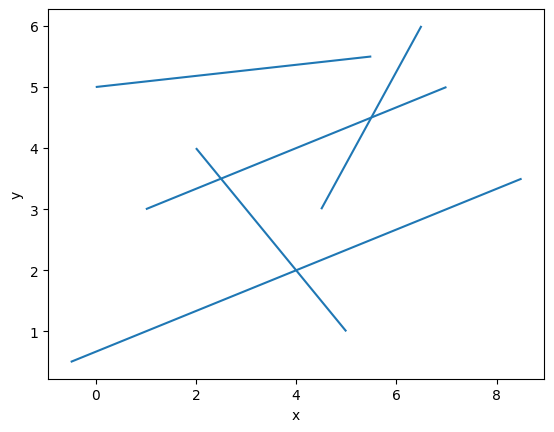

In [5]:
draw_example_1()

### Przykładowy zbiór odcinków po wyznaczenu punktów przecięcia

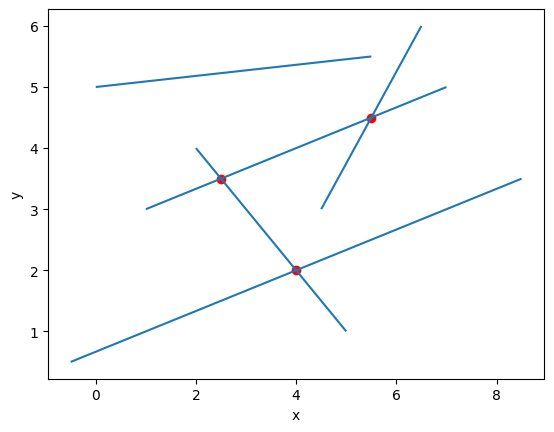

In [6]:
draw_example_2()

# Generowanie losowych odcinków na płaszczyźnie

Uzupełnij funkcję ```generate_uniform_sections```

In [7]:
def generate_uniform_sections(max_x, max_y, n):
    """
    Funkcja generuje odcinki o współrzędnych rzeczywistych w postaci par punktów. 
    Żaden wygenerowany odcinek nie jest odcinkiem pionowym.
    Żadne dwa odcinki nie mają swoich końców o takiej samej współrzędnej x.
    Zakres współrzędnych: x -> (0, max_x), y -> (0, max_y)
    :param max_x: określa maksymalną wartość współrzednej x jaka może zostać wylosowana
    :param max_y: określa maksymalną wartość współrzednej y jaka może zostać wylosowana
    :param n: ilość generowanych odcinków
    :return: tablica odcinków w postaci krotek zawierających parę krotek współrzędnych punktów końcowych odcinków
    np. [((x1, y1), (x2, y2)), ((x3, y3), (x4, y4)),...]
    """
    unique_x = set()
    while len(unique_x) < 2 * n:
        unique_x.add(random.uniform(0, max_x))
    
    x_coords = list(unique_x)
    random.shuffle(x_coords)
    
    segments = []
    
    for i in range(n):
        x1 = x_coords[2 * i]
        x2 = x_coords[2 * i + 1]
        
        y1 = random.uniform(0, max_y)
        y2 = random.uniform(0, max_y)
        
        segment = ((x1, y1), (x2, y2))
        segments.append(segment)
        
    return segments

In [8]:
Test().runtest(1, generate_uniform_sections)

Lab 4, task 1:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
Result: 3/3
Time: 0.322s


<span style="color:red">Ćw.</span> Wygeneruj $\large20$ losowych odcinków w przestrzeni 2D o współrzędnych z przedziału $\large x \in \langle 0,1000 \rangle$ oraz $\large y \in \langle 0,1000\rangle$. 

In [9]:
section = generate_uniform_sections(1000, 1000, 10)

Zwizualizuj otrzymane odcinki

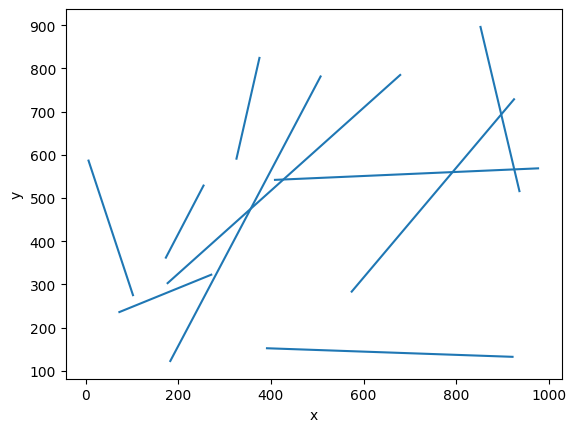

In [10]:
vis = Visualizer()
vis.add_line_segment(section)
vis.show()

Uzupełnij funkcję ```add_sections``` #interaktywne dodawanie odcinków przez rysowanie myszką

In [11]:
def add_sections(sections):
    vis = Visualizer()
    vis.add_line_segment(sections)
    vis.show()

Metody pomocnicze

In [12]:
class peakType:
    START = 0
    INTERSECTION = 1
    END = 2

class Event:
    """
    Klasa reprezentująca zdarzenie w algorytmie zamiatania.
    """
    def __init__(self, x, y, type, segment, other_segment=None):
        self.x = x
        self.y = y
        self.type = type
        self.segment = segment
        self.other_segment = other_segment
        
    def __lt__(self, other):
        # Sortowanie zdarzeń: najpierw po X, potem po Y, na końcu po typie
        return (self.x, self.y, self.type) < (other.x, other.y, other.type)

def det(a, b, c):
    """
    Oblicza wyznacznik macierzy 3x3 dla punktów a, b, c.
    Służy do określania orientacji punktów.
    """
    return (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])

def on_segment(p, a, b, eps=1e-24):
    """
    Sprawdza, czy punkt p leży na odcinku ab.
    Zakładamy, że p jest współliniowy z ab.
    """
    return min(a[0], b[0]) <= p[0] <= max(a[0], b[0]) and \
           min(a[1], b[1]) <= p[1] <= max(a[1], b[1]) and \
           math.abs(det(a, b, p)) < eps

def do_intersect(s1, s2,eps = 1e-24):
    """
    Sprawdza, czy dwa odcinki s1 i s2 się przecinają.
    """
    p1, q1 = s1
    p2, q2 = s2
    
    d1 = det(p1, q1, p2)
    d2 = det(p1, q1, q2)
    d3 = det(p2, q2, p1)
    d4 = det(p2, q2, q1)

    # Przypadek ogólny: końce jednego odcinka leżą po przeciwnych stronach drugiego
    if ((d1 > 0 and d2 < 0) or (d1 < 0 and d2 > 0)) and \
       ((d3 > 0 and d4 < 0) or (d3 < 0 and d4 > 0)):
        return True

    # Przypadki szczególne: współliniowość
    if abs(d1) < eps and on_segment(p2, p1, q1): return True
    if abs(d2) < eps and on_segment(q2, p1, q1): return True
    if abs(d3) < eps and on_segment(p1, p2, q2): return True
    if abs(d4) < eps and on_segment(q1, p2, q2): return True
    
    return False

def get_intersection(s1, s2,eps = 1e-24):
    """
    Oblicza punkt przecięcia dwóch odcinków s1 i s2.
    Zwraca krotkę (x, y) lub None, jeśli są równoległe.
    """
    x1, y1 = s1[0]
    x2, y2 = s1[1]
    x3, y3 = s2[0]
    x4, y4 = s2[1]
    
    denom = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(denom)< eps:
        return None
    
    px = ((x1*y2 - y1*x2)*(x3 - x4) - (x1 - x2)*(x3*y4 - y3*x4)) / denom
    py = ((x1*y2 - y1*x2)*(y3 - y4) - (y1 - y2)*(x3*y4 - y3*x4)) / denom
    return (px, py)

def get_y(segment, x):
    """
    Oblicza wartość Y na odcinku dla danej współrzędnej X.
    """
    p1, p2 = segment
    m = (p2[1] - p1[1]) / (p2[0] - p1[0])
    return p1[1] + m * (x - p1[0])

Uzupełnij funkcję ```is_intersection```

In [13]:
def is_intersection(sections):
    """
    Funkcja sprawdza czy jakakolwiek para podanych odcinków się przecina 
    :param sections: tablica odcinków w postaci krotek krotek współrzędnych punktów końcowych odcinków
    :param eps: epsilon będący dokładnością, z jaką porównujemy liczby zmiennoprzecinkowe
    :return: True / False
    """
    events = []
    for s in sections:
        p1, p2 = sorted(s)
        events.append(Event(p1[0], p1[1], 0, s))
        events.append(Event(p2[0], p2[1], 2, s))
        
    events.sort()
    
    active_segments = []
    
    for event in events:
        current_x = event.x
        
        if event.type == peakType.START: 
            segment = event.segment
            active_segments.append(segment)
            # Sortujemy aktywne odcinki według ich współrzędnej Y dla aktualnego X miotły
            active_segments.sort(key=lambda s: get_y(s, current_x))
            
            idx = active_segments.index(segment)
            
            # Sprawdzamy przecięcie z sąsiadem powyżej
            if idx > 0:
                if do_intersect(segment, active_segments[idx-1]):
                    return True
            # Sprawdzamy przecięcie z sąsiadem poniżej
            if idx < len(active_segments) - 1:
                if do_intersect(segment, active_segments[idx+1]):
                    return True
                    
        elif event.type == peakType.END: 
            segment = event.segment
            if segment in active_segments:
                idx = active_segments.index(segment)
                
                # Przed usunięciem sprawdzamy, czy sąsiedzi usuwanego odcinka się przecinają
                if idx > 0 and idx < len(active_segments) - 1:
                    if do_intersect(active_segments[idx-1], active_segments[idx+1]):
                        return True
                        
                active_segments.remove(segment)
                
    return False

In [14]:
Test().runtest(2, is_intersection)

Lab 4, task 2:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
Result: 3/3
Time: 0.003s


### W jaki sposób zaimplementowałeś struktura stanu (stan miotły) oraz struktura zdarzeń w Twoim programie?

**Struktura stanu**: Zaimplementowano jako listę aktywnych odcinków (`active_segments`), która jest sortowana przy każdym dodaniu nowego odcinka lub zmianie kolejności. Sortowanie odbywa się na podstawie współrzędnej Y przecięcia odcinka z aktualną pozycją miotły (X). W pełnej implementacji dla dużej liczby odcinków należałoby użyć zbalansowanego drzewa poszukiwań binarnych (BST), aby operacje wstawiania, usuwania i wyszukiwania sąsiadów były wykonywane w czasie $O(\log N)$. W Pythonie, dla uproszczenia i przy małej liczbie danych, lista sortowana jest akceptowalna, choć daje złożoność $O(N)$ na operację (łącznie $O(N^2)$).

**Struktura zdarzeń**: Zaimplementowano jako listę zdarzeń (`events`), która jest sortowana według współrzędnej X (a następnie Y i typu zdarzenia). Zdarzenia to obiekty klasy `Event` przechowujące współrzędne, typ (0: początek, 1: przecięcie, 2: koniec) oraz odniesienia do odcinków. W optymalnej wersji używa się kolejki priorytetowej (kopca).

Uzupełnij funkcję ```is_intersection_with_visualization```

In [15]:
def is_intersection_with_visualization(sections):
    vis = Visualizer()
    vis.add_line_segment(sections, color='blue')
    
    events = []
    for s in sections:
        p1, p2 = sorted(s)
        events.append(Event(p1[0], p1[1], 0, s))
        events.append(Event(p2[0], p2[1], 2, s))
        
    events.sort()
    
    active_segments = []
    
    # Dodajemy początkową linię zamiatania (poza zakresem)
    min_x = min(e.x for e in events) - 1
    max_y = max(max(s[0][1], s[1][1]) for s in sections) + 1
    min_y = min(min(s[0][1], s[1][1]) for s in sections) - 1
    
    sweep_line = vis.add_line_segment([((min_x, min_y), (min_x, max_y))], color='red')
    vis.remove_figure(sweep_line)

    for event in events:
        current_x = event.x
        
        # Aktualizacja linii zamiatania
        sweep_line = vis.add_line_segment([((current_x, min_y), (current_x, max_y))], color='red')
        
        if event.type == peakType.START: # Początek
            segment = event.segment
            active_segments.append(segment)
            active_segments.sort(key=lambda s: get_y(s, current_x))
            idx = active_segments.index(segment)
            
            if idx > 0:
                if do_intersect(segment, active_segments[idx-1]):
                    vis.add_point(get_intersection(segment, active_segments[idx-1]), color='red')
                    return True, vis
            if idx < len(active_segments) - 1:
                if do_intersect(segment, active_segments[idx+1]):
                    vis.add_point(get_intersection(segment, active_segments[idx+1]), color='red')
                    return True, vis
                    
        elif event.type == peakType.END:
            segment = event.segment
            if segment in active_segments:
                idx = active_segments.index(segment)
                if idx > 0 and idx < len(active_segments) - 1:
                    if do_intersect(active_segments[idx-1], active_segments[idx+1]):
                        vis.add_point(get_intersection(active_segments[idx-1], active_segments[idx+1]), color='red')
                        return True, vis
                active_segments.remove(segment)
        
        vis.remove_figure(sweep_line)
                
    return False, vis

Uzupełnij funkcję ```find_intersections```

In [ ]:
def find_intersections(sections):
    # Przygotowanie danych: dodajemy identyfikatory do odcinków
    indexed_sections = []
    for i, s in enumerate(sections):
        p1, p2 = sorted(s)
        indexed_sections.append({'p1': p1, 'p2': p2, 'id': i + 1, 'seg': s})
        
    events = []
    for s in indexed_sections:
        events.append(Event(s['p1'][0], s['p1'][1], peakType.START, s))
        events.append(Event(s['p2'][0], s['p2'][1], peakType.END, s))
        
    events.sort()
    
    active_segments = []
    intersections = {}
    
    # Funkcja pomocnicza do sprawdzania i dodawania nowych zdarzeń przecięcia
    def check_intersection(s1, s2, current_x):
        if do_intersect(s1['seg'], s2['seg']):
            pt = get_intersection(s1['seg'], s2['seg'])
            # Interesują nas tylko przecięcia na prawo od miotły
            if pt and pt[0] > current_x:
                events.append(Event(pt[0], pt[1], peakType.INTERSECTION, s1, s2))
                events.sort()

    while events:
        event = events.pop(0)
        current_x = event.x
        
        if event.type == peakType.START: # Początek odcinka
            segment = event.segment
            active_segments.append(segment)
            active_segments.sort(key=lambda s: get_y(s['seg'], current_x))
            
            idx = active_segments.index(segment)
            
            # Sprawdzamy sąsiadów
            if idx > 0:
                check_intersection(segment, active_segments[idx-1], current_x)
            if idx < len(active_segments) - 1:
                check_intersection(segment, active_segments[idx+1], current_x)
                
        elif event.type == peakType.END: # Koniec odcinka
            segment = event.segment
            if segment in active_segments:
                idx = active_segments.index(segment)
                # Sprawdzamy czy sąsiedzi usuwanego odcinka się przecinają
                if idx > 0 and idx < len(active_segments) - 1:
                    check_intersection(active_segments[idx-1], active_segments[idx+1], current_x)
                active_segments.remove(segment)
                
        elif event.type == peakType.INTERSECTION: # Przecięcie
            s1 = event.segment
            s2 = event.other_segment
            
            # Dodajemy przecięcie do wyników (unikając duplikatów)
            id1, id2 = sorted((s1['id'], s2['id']))
            intersection_tuple = (id1,id2)
            
            if intersection_tuple not in intersections.keys():
                intersections[intersection_tuple]=(event.x,event.y)
            
            # Zamieniamy odcinki miejscami w strukturze stanu 
                if s1 in active_segments and s2 in active_segments:
                    i1 = active_segments.index(s1)
                    i2 = active_segments.index(s2)
                    active_segments[i1], active_segments[i2] = active_segments[i2], active_segments[i1]
                    
                    # Po zamianie sprawdzamy nowych sąsiadów
                    # s1 i s2 zamieniły się miejscami, więc sprawdzamy ich nowych "zewnętrznych" sąsiadów
                    idx_lower = min(i1, i2)
                    idx_upper = max(i1, i2)
                    
                    segment_lower = active_segments[idx_lower]
                    segment_upper = active_segments[idx_upper]
                    
                    if idx_lower > 0:
                        check_intersection(segment_lower, active_segments[idx_lower-1], current_x)
                    if idx_upper < len(active_segments) - 1:
                        check_intersection(segment_upper, active_segments[idx_upper+1], current_x)
    output = []
    for key in intersections.keys(): #zamiana słownika na listę aby przeszło testy nie jest to konieczne w końcowym rozwiązaniu
        point = intersections.get(key)
        output.append((point,key[0],key[1]))

    return output

In [76]:
Test().runtest(3, find_intersections)

Lab 4, task 3:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
Result: 3/3
Time: 0.008s


Uzupełnij funkcję ```find_intersections_with_visualization```

In [77]:
def find_intersections_with_visualization(sections):
    vis = Visualizer()
    vis.add_line_segment(sections, color='black')
    
    indexed_sections = []
    for i, s in enumerate(sections):
        p1, p2 = sorted(s)
        indexed_sections.append({'p1': p1, 'p2': p2, 'id': i + 1, 'seg': s})
        
    events = []
    for s in indexed_sections:
        events.append(Event(s['p1'][0], s['p1'][1], peakType.START, s))
        events.append(Event(s['p2'][0], s['p2'][1], peakType.END, s))
        
    events.sort()
    
    active_segments = []
    intersections = {}
    
    # Zakres Y dla linii zamiatania
    if sections:
        max_y = max(max(s[0][1], s[1][1]) for s in sections) + 1
        min_y = min(min(s[0][1], s[1][1]) for s in sections) - 1
    else:
        max_y, min_y = 10, 0

    def check_intersection(s1, s2, current_x):
        if do_intersect(s1['seg'], s2['seg']):
            pt = get_intersection(s1['seg'], s2['seg'])
            if pt and pt[0] > current_x:
                events.append(Event(pt[0], pt[1], peakType.INTERSECTION, s1, s2))
                vis.add_point((pt[0],pt[1]), color='red')
                events.sort()

    while events:
        event = events.pop(0)
        current_x = event.x
        
        sweep_line = vis.add_line_segment([((current_x, min_y), (current_x, max_y))], color='red')
        
        if event.type == peakType.START: # Początek
            segment = event.segment
            active_segments.append(segment)
            vis.add_line_segment((segment['p1'],segment['p2']),color="green")
            active_segments.sort(key=lambda s: get_y(s['seg'], current_x))
            idx = active_segments.index(segment)
            
            if idx > 0: check_intersection(segment, active_segments[idx-1], current_x)
            if idx < len(active_segments) - 1: check_intersection(segment, active_segments[idx+1], current_x)
                
        elif event.type == peakType.END: # Koniec
            segment = event.segment
            if segment in active_segments:
                idx = active_segments.index(segment)
                if idx > 0 and idx < len(active_segments) - 1:
                    check_intersection(active_segments[idx-1], active_segments[idx+1], current_x)
                active_segments.remove(segment)
                vis.add_line_segment((segment['p1'],segment['p2']),color="yellow")
                
        elif event.type == peakType.INTERSECTION: # Przecięcie
            s1 = event.segment
            s2 = event.other_segment
            
            id1, id2 = sorted((s1['id'], s2['id']))
            intersection_tuple = (id1,id2)
            
            if intersection_tuple not in intersections.keys():
                intersections[intersection_tuple]=(event.x,event.y)
            
                if s1 in active_segments and s2 in active_segments:
                    i1 = active_segments.index(s1)
                    i2 = active_segments.index(s2)
                    active_segments[i1], active_segments[i2] = active_segments[i2], active_segments[i1]
                    
                    idx_lower = min(i1, i2)
                    idx_upper = max(i1, i2)
                    
                    if idx_lower > 0:
                        check_intersection(active_segments[idx_lower], active_segments[idx_lower-1], current_x)
                    if idx_upper < len(active_segments) - 1:
                        check_intersection(active_segments[idx_upper], active_segments[idx_upper+1], current_x)
        
        vis.remove_figure(sweep_line)

    return intersections, vis


### Czy konieczne były zmiany w strukturze zdarzeń. Jeśli tak, to jakie? Czy w przypadku obu algorytmów konieczne są takie same struktury zdarzeń?
### Odpowiedź uzasadnij. 

Tak, dla algorytmu `find_intersections` (znajdowanie wszystkich przecięć) konieczne było dodanie obsługi zdarzeń typu "przecięcie" (intersection), które są generowane dynamicznie w trakcie działania algorytmu. 
Dla `is_intersection` (wykrywanie czy istnieje jakiekolwiek przecięcie) wystarczą zdarzenia początku i końca odcinków, ponieważ algorytm kończy działanie natychmiast przy pierwszym wykrytym przecięciu, więc nie musimy przetwarzać zdarzeń przecięcia, aby kontynuować zamiatanie.

### Jak obsługiwane są zdarzenia początku odcinka, końca odcinka i przecięcia odcinków z uwzględnianiem wybranych struktur danych?

1.  **Początek odcinka**: Odcinek jest dodawany do struktury stanu. Następuje sprawdzenie czy przecina się on ze swoimi bezpośrednimi sąsiadami (powyżej i poniżej) w strukturze stanu. Jeśli tak, i przecięcie jest na prawo od miotły, dodawane jest zdarzenie przecięcia.
2.  **Koniec odcinka**: Odcinek jest usuwany ze struktury stanu. Sprawdzane jest, czy jego dotychczasowi sąsiedzi (którzy teraz stają się sąsiadami siebie nawzajem) przecinają się.
3.  **Przecięcie odcinków**: Odcinki biorące udział w przecięciu zamieniają się miejscami w strukturze stanu (ich kolejność Y się odwraca). Następnie sprawdzane są przecięcia tych odcinków z ich nowymi sąsiadami.

W funkcji `find_intersections` zaimplementowano mechanizmy zapobiegające duplikatom:
1.  Przy dodawaniu znalezionego przecięcia do listy wyników sprawdzane jest, czy taki punkt (dla danej pary odcinków) już tam istnieje (`if intersection_tuple not in intersections.keys()`).
2.  Zdarzenia przecięcia są dodawane tylko jeśli punkt przecięcia ma współrzędną X większą od aktualnej pozycji miotły, co zapobiega cofaniu się i ponownemu wykrywaniu tych samych przecięć w przeszłości.

In [68]:
section1 = [
    ((np.float64(12.10), np.float64(78.25)), (np.float64(39.44), np.float64(84.20))),
    ((np.float64(12.90), np.float64(57.68)), (np.float64(32.50), np.float64(39.83))),
    ((np.float64(33.31), np.float64(56.71)), (np.float64(58.23), np.float64(85.39))),
    ((np.float64(48.79), np.float64(50.87)), (np.float64(33.06), np.float64(24.89))),
    ((np.float64(40.97), np.float64(15.15)), (np.float64(72.50), np.float64(15.04))),
    ((np.float64(74.76), np.float64(27.49)), (np.float64(51.61), np.float64(56.28))),
    ((np.float64(10.16), np.float64(21.43)), (np.float64(22.50), np.float64(14.94))),
    ((np.float64(80.89), np.float64(75.54)), (np.float64(89.27), np.float64(31.60))),
    ((np.float64(57.50), np.float64(66.34)), (np.float64(78.15), np.float64(49.13))),
    ((np.float64(70.97), np.float64(83.98)), (np.float64(92.34), np.float64(93.61))),
    ((np.float64(79.60), np.float64(7.03)), (np.float64(94.84), np.float64(26.08)))
]

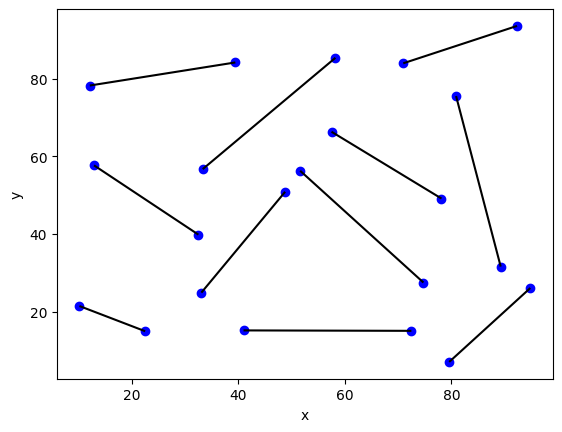

In [69]:
vis = Visualizer()
vis.add_line_segment(section1,color="black")
for points in section1:
    vis.add_point(points[0],color="blue")
    vis.add_point(points[1],color="blue")
vis.show()

Czy istnieją przecięcia False
Ilosc przeciec: 0
przeciecia: []


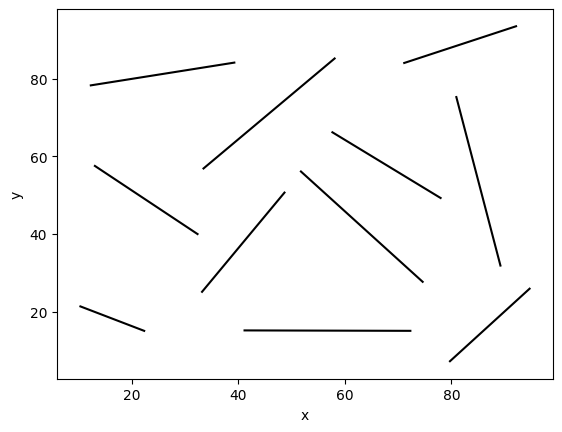

In [71]:
intersections = find_intersections(section1)
print(f'Czy istnieją przecięcia {is_intersection(section1)}')
print(f'Ilosc przeciec: {len(intersections)}')
print(f'przeciecia: {intersections}')
vis = Visualizer()
vis.add_line_segment(section1,color="black")
for intersection in intersections:
    vis.add_point(intersection[0],color="red")
vis.show()

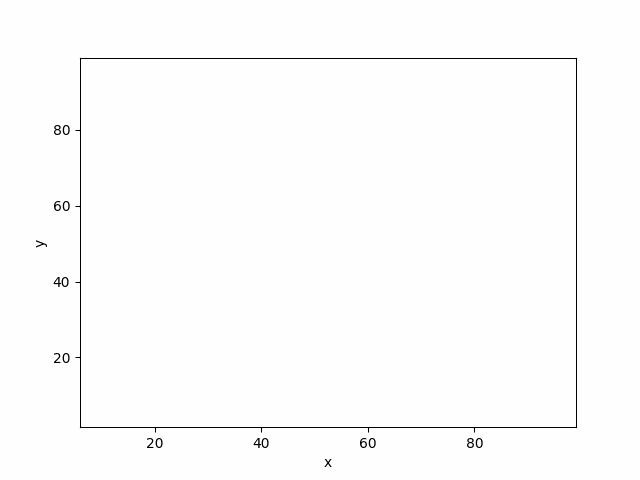

In [ ]:
intersections,vis = find_intersections_with_visualization(section1)
vis.show_gif()

In [ ]:
section2 = [
    ((np.float64(11.37), np.float64(11.04)), (np.float64(38.55), np.float64(57.58))),
    ((np.float64(8.95), np.float64(21.86)), (np.float64(60.00), np.float64(8.01))),
    ((np.float64(47.26), np.float64(5.19)), (np.float64(77.50), np.float64(38.64))),
    ((np.float64(17.82), np.float64(48.27)), (np.float64(80.16), np.float64(24.35))),
    ((np.float64(17.74), np.float64(87.77)), (np.float64(79.11), np.float64(11.47))),
    ((np.float64(34.76), np.float64(30.19)), (np.float64(83.31), np.float64(93.18))),
    ((np.float64(62.74), np.float64(85.39)), (np.float64(92.34), np.float64(51.08))),
    ((np.float64(22.10), np.float64(55.09)), (np.float64(95.08), np.float64(55.41)))
]

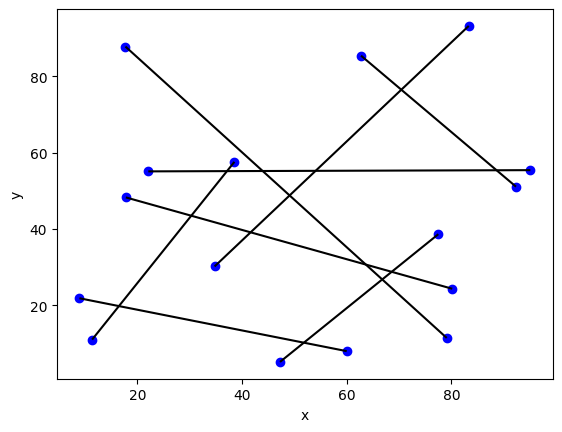

In [40]:
vis = Visualizer()
vis.add_line_segment(section2,color="black")
for points in section2:
    vis.add_point(points[0],color="blue")
    vis.add_point(points[1],color="blue")
vis.show()

Czy istnieją przecięcia True
Ilosc przeciec: 13
przeciecia: [((16.49376146582326, 19.813357565099864), 1, 2), ((30.313251615706626, 43.476310897534454), 1, 4), ((37.13430503340289, 55.15592186367072), 1, 8), ((41.64828339215606, 39.12703338562123), 4, 6), ((43.94828808325479, 55.18579956408115), 5, 8), ((49.09437468069116, 48.78778086790394), 5, 6), ((51.816521125737225, 10.230199459520852), 2, 3), ((54.059867029699745, 55.230136440798915), 6, 8), ((63.65716703629016, 30.682174598844075), 4, 5), ((66.78747419927143, 26.79033108351949), 3, 5), ((68.59351640442698, 28.788086102119138), 3, 4), ((70.43292811042376, 76.47296069362704), 6, 7), ((88.628816454484, 55.38171308941402), 7, 8)]


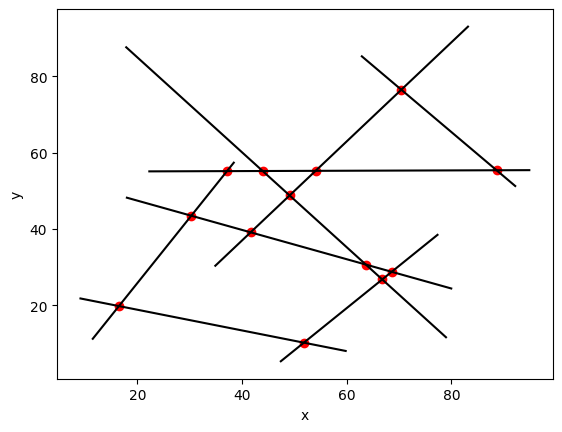

In [72]:
intersections = find_intersections(section2)
print(f'Czy istnieją przecięcia {is_intersection(section2)}')
print(f'Ilosc przeciec: {len(intersections)}')
print(f'przeciecia: {intersections}')
vis = Visualizer()
vis.add_line_segment(section2,color="black")
for intersection in intersections:
    vis.add_point(intersection[0],color="red")
vis.show()

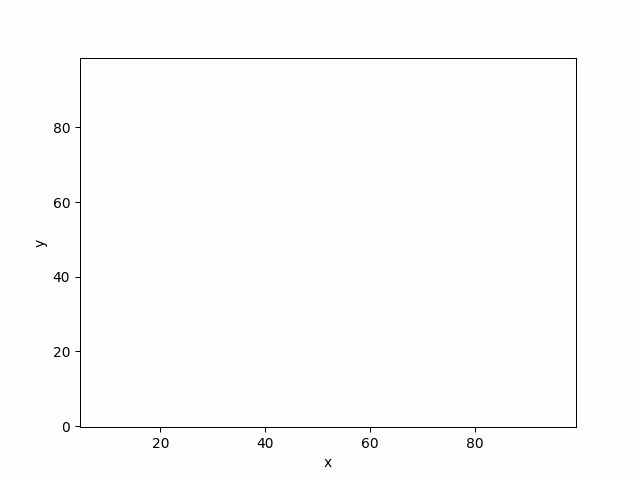

In [44]:
intersections,vis = find_intersections_with_visualization(section2)
vis.show_gif()

In [64]:
section3 = [
    ((np.float64(19.52), np.float64(83.23)), (np.float64(76.21), np.float64(78.35))),
    ((np.float64(30.89), np.float64(67.97)), (np.float64(74.68), np.float64(16.13))),
    ((np.float64(8.79), np.float64(24.68)), (np.float64(41.29), np.float64(48.05))),
    ((np.float64(30.08), np.float64(51.41)), (np.float64(74.60), np.float64(59.85))),
    ((np.float64(53.47), np.float64(7.90)), (np.float64(88.79), np.float64(8.77))),
    ((np.float64(60.08), np.float64(86.90)), (np.float64(90.32), np.float64(59.31))),
    ((np.float64(21.45), np.float64(5.74)), (np.float64(43.87), np.float64(17.64))),
    ((np.float64(12.66), np.float64(75.76)), (np.float64(39.19), np.float64(72.29))),
    ((np.float64(7.98), np.float64(66.88)), (np.float64(20.97), np.float64(50.32))),
    ((np.float64(78.15), np.float64(21.86)), (np.float64(79.76), np.float64(52.16)))
]

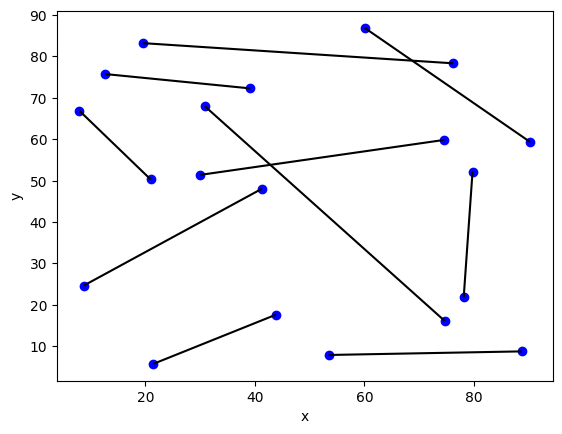

In [65]:
vis = Visualizer()
vis.add_line_segment(section3,color="black")
for points in section3:
    vis.add_point(points[0],color="blue")
    vis.add_point(points[1],color="blue")
vis.show()

Czy istnieją przecięcia True
Ilosc przeciec: 2
przeciecia: [((np.float64(42.835774614600076), np.float64(53.82821064122246)), 2, 4), ((np.float64(68.74709374383829), np.float64(78.99242339971897)), 1, 6)]


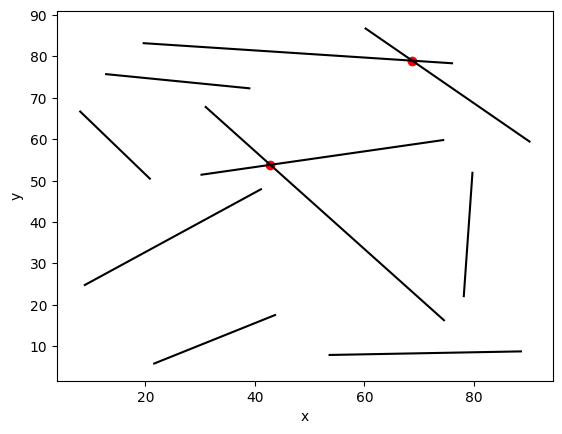

In [73]:
intersections = find_intersections(section3)
print(f'Czy istnieją przecięcia {is_intersection(section3)}')
print(f'Ilosc przeciec: {len(intersections)}')
print(f'przeciecia: {intersections}')
vis = Visualizer()
vis.add_line_segment(section3,color="black")
for intersection in intersections:
    vis.add_point(intersection[0],color="red")
vis.show()

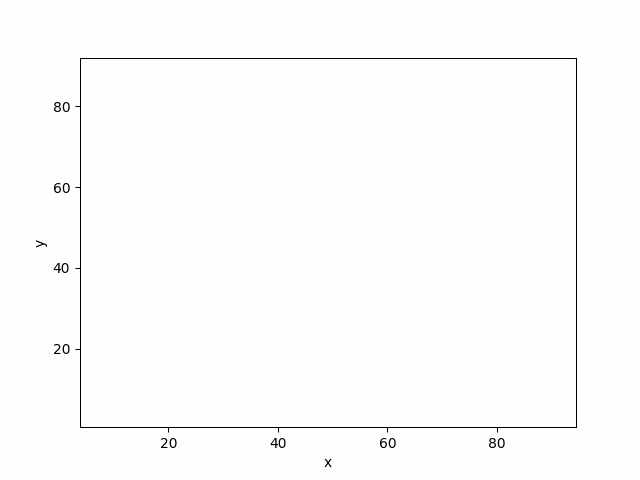

In [86]:
intersections,vis = find_intersections_with_visualization(section3)
vis.show_gif()

In [82]:
section4 = [
((np.float64(0.32), np.float64(9.61)),(np.float64(9.69), np.float64(0.34))),
((np.float64(0.19), np.float64(0.29)),(np.float64(9.59), np.float64(9.76))), 
((np.float64(2.62), np.float64(5.11)),(np.float64(3.35), np.float64(5.1))),
((np.float64(6.07), np.float64(5.1)),(np.float64(6.82), np.float64(5.14)))
]

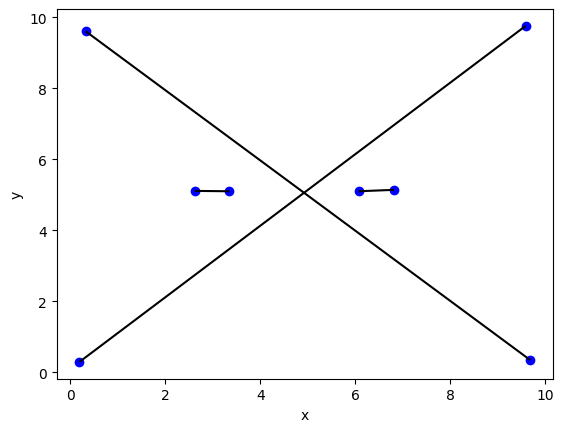

In [83]:
vis = Visualizer()
vis.add_line_segment(section4,color="black")
for points in section4:
    vis.add_point(points[0],color="blue")
    vis.add_point(points[1],color="blue")
vis.show()

Czy istnieją przecięcia True
Ilosc przeciec: 1
przeciecia: [((np.float64(4.921937847945009), np.float64(5.057175682982898)), 1, 2)]


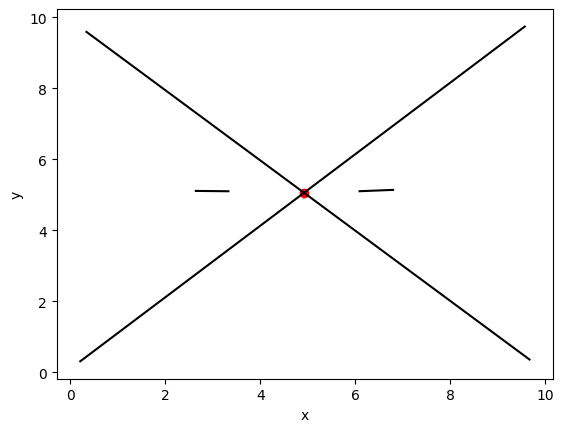

In [84]:
intersections = find_intersections(section4)
print(f'Czy istnieją przecięcia {is_intersection(section4)}')
print(f'Ilosc przeciec: {len(intersections)}')
print(f'przeciecia: {intersections}')
vis = Visualizer()
vis.add_line_segment(section4,color="black")
for intersection in intersections:
    vis.add_point(intersection[0],color="red")
vis.show()

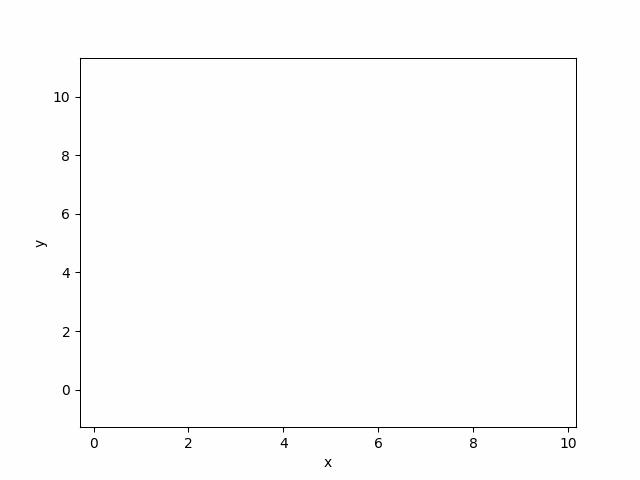

In [85]:
intersections,vis = find_intersections_with_visualization(section4)
vis.show_gif()